In [1]:
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Portuguese Project/bank-full.csv", sep=";")

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [8]:
df["y"].value_counts()

,count
y,
no,39922
yes,5289


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

job ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital ['married' 'single' 'divorced']
education ['tertiary' 'secondary' 'unknown' 'primary']
default ['no' 'yes']
housing ['yes' 'no']
loan ['no' 'yes']
contact ['unknown' 'cellular' 'telephone']
month ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome ['unknown' 'failure' 'other' 'success']
y ['no' 'yes']


In [11]:
for col in ['job','education','contact','poutcome']:
    df[col]=df[col].replace("unknown",df[col].mode()[0])

In [12]:
# Feature Engineering

df['was_contacted_before'] = (df['pdays'] != -1).astype(int)

def group_job(job):
    if job in ['management', 'professional', 'admin.', 'technician']:
        return 'white_collar'
    elif job in ['blue-collar', 'services', 'housemaid']:
        return 'blue_collar'
    elif job in ['retired', 'student', 'unemployed']:
        return 'low_income_inactive'
    else:
        return 'self_employed'

df['job_tier'] = df['job'].apply(group_job)

df['pdays_bucket'] = pd.cut(df['pdays'], bins=[-2,-1,30,90,180,1000],
                              labels=['never','recent','1-3mo','3-6mo','6mo+'])
df['campaign_bucket'] = pd.cut(df['campaign'], bins=[0,1,3,6,100],
                                 labels=['1','2-3','4-6','7+'])
df['balance_bucket'] = pd.qcut(df['balance'], q=5, duplicates='drop')
df['age_bucket'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100])

In [13]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

encoded=ohe.fit_transform(df[["job","marital","education","default","housing","loan","contact","month","poutcome",'job_tier','pdays_bucket','campaign_bucket','balance_bucket','age_bucket']])

df_encoded=pd.get_dummies(df,columns=["job","marital","education","default","housing","loan","contact","month","poutcome",'job_tier','pdays_bucket','campaign_bucket','balance_bucket','age_bucket'], dtype=int)

df_encoded["y"]=df_encoded['y'].map({"yes":1,"no":0})

df_encoded.columns = df_encoded.columns.str.replace(r'[\[\]<,]', '', regex=True)

In [14]:
df_encoded

,age,balance,day,duration,campaign,pdays,previous,y,was_contacted_before,job_admin.,...,balance_bucket_(22.0 272.0,balance_bucket_(272.0 701.0,balance_bucket_(701.0 1859.0,balance_bucket_(1859.0 102127.0,age_bucket_(17 25,age_bucket_(25 35,age_bucket_(35 45,age_bucket_(45 55,age_bucket_(55 65,age_bucket_(65 100
0,58,2143,5,261,1,-1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,44,29,5,151,1,-1,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2,33,2,5,76,1,-1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,47,1506,5,92,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,33,1,5,198,1,-1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0
45207,71,1729,17,456,2,-1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
45208,72,5715,17,1127,5,184,3,1,1,0,...,0,0,0,1,0,0,0,0,0,1
45209,57,668,17,508,4,-1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [15]:
!pip install xgboost

In [16]:
from sklearn.model_selection import train_test_split

x=df_encoded.drop(['y','duration'],axis=1)

y=df_encoded['y']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=49,stratify=y)

In [17]:
import xgboost as xgb

xgbc=xgb.XGBClassifier()

model=xgbc.fit(x_train,y_train)

y_pred=model.predict(x_test)

In [18]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

accuracy_score(y_test,y_pred)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.59      0.27      0.37      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.62      0.65      9043
weighted avg       0.87      0.89      0.87      9043



In [19]:
confusion_matrix(y_test,y_pred)

array([[7788,  197],
       [ 777,  281]])

In [20]:
x_train

,age,balance,day,campaign,pdays,previous,was_contacted_before,job_admin.,job_blue-collar,job_entrepreneur,...,balance_bucket_(22.0 272.0,balance_bucket_(272.0 701.0,balance_bucket_(701.0 1859.0,balance_bucket_(1859.0 102127.0,age_bucket_(17 25,age_bucket_(25 35,age_bucket_(35 45,age_bucket_(45 55,age_bucket_(55 65,age_bucket_(65 100
33698,63,2193,21,4,-1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
10519,51,721,16,3,-1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4101,44,2,19,1,-1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
31189,75,1470,27,1,-1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1914,25,61,9,9,-1,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13926,30,5,10,5,-1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
9357,44,248,6,1,-1,0,0,1,0,0,...,1,0,0,0,0,0,1,0,0,0
19416,46,225,6,5,-1,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
24453,39,0,17,1,-1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [21]:
from sklearn.model_selection import RandomizedSearchCV

neg,pos = (df_encoded['y']==0).sum(),(df_encoded['y']==1).sum()
scale_pos_weight= neg/pos
print(scale_pos_weight)

param_grid = {
    "n_estimators": (100, 150, 200, 250, 300),
    "max_depth": (3, 4, 5, 6),              # capped at 6 (was up to 16) — shallower trees generalize better
    "learning_rate": (0.01, 0.03, 0.05, 0.1),
    "subsample": (0.6, 0.7, 0.8),
    "colsample_bytree": (0.5, 0.6, 0.7),
    "min_child_weight": (10, 20, 30, 50),   # raised (was as low as 5) — forces more robust splits
    "gamma": (0.1, 0.3, 0.5, 1),            # raised minimum loss reduction to split
    "reg_alpha": (0.1, 1, 5),               # stronger L1
    "reg_lambda": (1, 2, 5, 10),            # stronger L2
}

rsv = RandomizedSearchCV(
    estimator=xgbc,
    param_distributions=param_grid,
    n_iter=50,                    # search more combinations from the wider, tighter-bounded grid
    cv=5,
    scoring="average_precision",  # more robust than "f1" for imbalanced classes
    n_jobs=1,
    verbose=3,
    random_state=49
)

model2 = rsv.fit(x_train, y_train)
print(model2.best_params_)


7.548118737001324
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.5, gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=30, n_estimators=150, reg_alpha=5, reg_lambda=5, subsample=0.6;, score=0.358 total time=   1.5s
[CV 2/5] END colsample_bytree=0.5, gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=30, n_estimators=150, reg_alpha=5, reg_lambda=5, subsample=0.6;, score=0.372 total time=   1.5s
[CV 3/5] END colsample_bytree=0.5, gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=30, n_estimators=150, reg_alpha=5, reg_lambda=5, subsample=0.6;, score=0.416 total time=   4.9s
[CV 4/5] END colsample_bytree=0.5, gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=30, n_estimators=150, reg_alpha=5, reg_lambda=5, subsample=0.6;, score=0.353 total time=   4.6s
[CV 5/5] END colsample_bytree=0.5, gamma=0.1, learning_rate=0.01, max_depth=3, min_child_weight=30, n_estimators=150, reg_alpha=5, reg_lambda=5, subsamp

In [22]:
model2.best_params_

{'subsample': 0.7,
 'reg_lambda': 10,
 'reg_alpha': 1,
 'n_estimators': 250,
 'min_child_weight': 10,
 'max_depth': 6,
 'learning_rate': 0.05,
 'gamma': 0.1,
 'colsample_bytree': 0.5}

In [23]:
y_test_predict2=model2.predict(x_test)

print(y_test_predict2)

from sklearn.metrics import accuracy_score, precision_score,f1_score,recall_score,classification_report,confusion_matrix

print(confusion_matrix(y_test,y_test_predict2))

print(classification_report(y_test,y_test_predict2))

[0 0 0 ... 0 0 0]
[[7837  148]
 [ 804  254]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.63      0.24      0.35      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.61      0.65      9043
weighted avg       0.87      0.89      0.87      9043



In [24]:
y_train_predict2=model2.predict(x_train)

print(y_train_predict2)

from sklearn.metrics import accuracy_score, precision_score,f1_score,recall_score,classification_report,confusion_matrix

print(confusion_matrix(y_train,y_train_predict2))

print(classification_report(y_train,y_train_predict2))

[0 0 0 ... 0 0 1]
[[31520   417]
 [ 3180  1051]]
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     31937
           1       0.72      0.25      0.37      4231

    accuracy                           0.90     36168
   macro avg       0.81      0.62      0.66     36168
weighted avg       0.89      0.90      0.88     36168



In [25]:
from sklearn.metrics import roc_curve,auc,roc_auc_score

false_positive, true_positive, thresholds = roc_curve(y_test, y_test_predict2)

roc_auc_score(y_test, y_test_predict2)

np.float64(0.610770430852745)

In [26]:
from sklearn.model_selection import train_test_split


x_train2,x_val,y_train2,y_val=train_test_split(x_train,y_train,test_size=0.20,random_state=49,stratify=y_train)

In [27]:
print(x_train.shape)
print(y_train.shape)

(36168, 72)
(36168,)


In [28]:
best_params_no_n = {k: v for k, v in model2.best_params_.items() if k != "n_estimators"}

xgbc_final = xgb.XGBClassifier(
    **best_params_no_n,
    n_estimators=2000,            # set high — early stopping decides the real number of trees
    eval_metric='aucpr',          # better than logloss for imbalanced data
    early_stopping_rounds=30,
    random_state=49
)

x_train2_orig, y_train2_orig = x_train2.copy(), y_train2.copy()

from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=49)
x_train2, y_train2 = smote_enn.fit_resample(x_train2, y_train2)

xgbc_final.fit(x_train2, y_train2, eval_set=[(x_val, y_val)], verbose=False)

print("Best iteration:", xgbc_final.best_iteration)
print(classification_report(y_test, xgbc_final.predict(x_test)))
print('AUC:', roc_auc_score(y_test, xgbc_final.predict_proba(x_test)[:,1]))


Best iteration: 300
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7985
           1       0.49      0.42      0.45      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.68      0.69      9043
weighted avg       0.87      0.88      0.88      9043

AUC: 0.7798268374184583


In [29]:
print(classification_report(y_val, xgbc_final.predict(x_val)))
print('AUC:', roc_auc_score(y_val, xgbc_final.predict_proba(x_val)[:,1]))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6388
           1       0.50      0.41      0.45       846

    accuracy                           0.88      7234
   macro avg       0.71      0.68      0.69      7234
weighted avg       0.87      0.88      0.88      7234

AUC: 0.795322679492133


In [30]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

y_val_proba = xgbc_final.predict_proba(x_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

# find threshold that maximizes F1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")

Best threshold: 0.434
Precision: 0.478, Recall: 0.465, F1: 0.471


In [31]:
y_test_proba = xgbc_final.predict_proba(x_test)[:, 1]
y_test_pred_tuned = (y_test_proba >= best_threshold).astype(int)

print(y_test_proba)

print(y_test_pred_tuned)

print(classification_report(y_test, y_test_pred_tuned))

[0.04670531 0.48417735 0.03910936 ... 0.10193081 0.10423056 0.07956773]
[0 1 0 ... 0 0 0]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.47      0.46      0.46      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.69      0.70      9043
weighted avg       0.87      0.88      0.88      9043



In [32]:
y_train_proba_orig = xgbc_final.predict_proba(x_train2_orig)[:, 1]
y_train_pred_tuned_orig = (y_train_proba_orig >= best_threshold).astype(int)

print(classification_report(y_train2_orig, y_train_pred_tuned_orig))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     25549
           1       0.49      0.48      0.49      3385

    accuracy                           0.88     28934
   macro avg       0.71      0.71      0.71     28934
weighted avg       0.88      0.88      0.88     28934



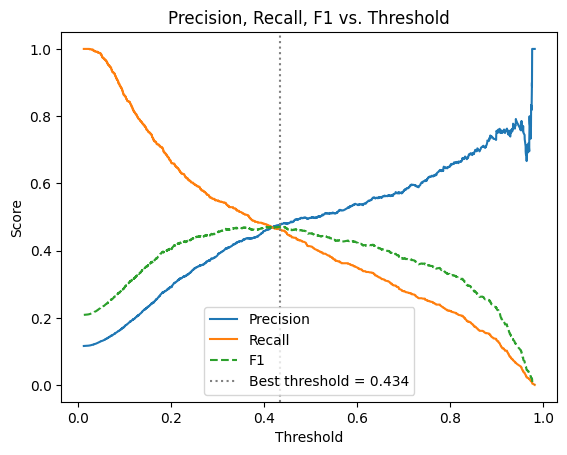

In [33]:
import matplotlib.pyplot as plt

false_positive, true_positive, roc_thresholds = roc_curve(y_test, y_test_predict2)

precisions, recalls, pr_thresholds = precision_recall_curve(y_val, y_val_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = pr_thresholds[best_idx]

plt.plot(pr_thresholds, precisions[:-1], label='Precision')
plt.plot(pr_thresholds, recalls[:-1], label='Recall')
plt.plot(pr_thresholds, f1_scores[:-1], label='F1', linestyle='--')
plt.axvline(best_threshold, color='gray', linestyle=':', label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs. Threshold')
plt.legend()
plt.show()


In [34]:
import numpy as np
high_thresh_mask = pr_thresholds > 0.85
print("Predicted positive counts at high thresholds:",
      [(t, (y_val_proba >= t).sum()) for t in pr_thresholds[high_thresh_mask][::20]])

Predicted positive counts at high thresholds: [(np.float32(0.85018295), np.int64(219)), (np.float32(0.8615998), np.int64(199)), (np.float32(0.8829335), np.int64(179)), (np.float32(0.8986003), np.int64(159)), (np.float32(0.90626204), np.int64(139)), (np.float32(0.9163189), np.int64(119)), (np.float32(0.9278979), np.int64(99)), (np.float32(0.9377331), np.int64(79)), (np.float32(0.95258754), np.int64(59)), (np.float32(0.9613463), np.int64(39)), (np.float32(0.97064656), np.int64(19))]


In [35]:
import pickle

# Recover the exact balance_bucket bin edges pd.qcut computed during
# training, so app.py can apply the SAME cuts to a single new row later
# (qcut needs a full distribution to compute quantiles from -- a single
# prediction row has no distribution of its own).
_, balance_bin_edges = pd.qcut(df['balance'], q=5, duplicates='drop', retbins=True)

bundle = {
    'model': xgbc_final,
    'feature_columns': x_train2_orig.columns.tolist(),  # exact trained column order
    'best_threshold': best_threshold,
    'balance_bins': balance_bin_edges,
}

# Saves directly into the same Google Drive folder as bank-full.csv --
# adjust the path if your project folder in Drive is named differently.
save_path = '/content/drive/MyDrive/Colab Notebooks/Portuguese Project/model.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(bundle, f)

print("Saved model.pkl with", len(bundle['feature_columns']), "feature columns")
print("Location:", save_path)

Saved model.pkl with 72 feature columns
Location: /content/drive/MyDrive/Colab Notebooks/Portuguese Project/model.pkl
